This assignment will help you apply semi-supervised learning techniques along with supervised models on a real-world dataset. You will work with the Breast Cancer Wisconsin Dataset (or any other tabular dataset with class labels). The goal is to compare supervised vs semi-supervised performance.

Dataset link (choose any one): https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original

<br>


  |Sl.No|Attribute|Domain|
  |-----|---------|------|
  | 1.| Sample code number         | id number |
  | 2.| Clump Thickness            |  1 - 10 |
  | 3.| Uniformity of Cell Size    |  1 - 10 |
  | 4.| Uniformity of Cell Shape   |  1 - 10 |
  | 5.| Marginal Adhesion          |  1 - 10 |
  | 6.| Single Epithelial Cell Size|  1 - 10 |
  | 7.| Bare Nuclei                |  1 - 10 |
  | 8.| Bland Chromatin            |  1 - 10 |
  | 9.| Normal Nucleoli            |  1 - 10 |
 | 10.| Mitoses                    |  1 - 10 |
 | 11.| Class:                     |  (2 for benign, 4 for malignant) |



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

1. Load and Explore the Dataset (2 Marks)
- Read the dataset
- Display basic statistics, missing values, and class distribution

In [2]:
# 1a. Read the dataset
cols = [
    "sample_code_number",
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class"
]

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/breast+cancer+wisconsin+original/breast-cancer-wisconsin.data", header=None, names=cols)
df

,sample_code_number,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
696,888820,5,10,10,3,7,3,8,10,2,4
697,897471,4,8,6,4,3,4,10,6,1,4


In [3]:
# 1b. Display basic statistics, missing values, and class distribution
print("========== Basic Statistics ==========")
print(df.info())


print("\n\n========== Drop duplicates ==========")
duplicates_mask = df.duplicated()
print(f"Dropped {len(df[duplicates_mask])} duplicates")
df = df.drop_duplicates()


print("\n\n========== Data Preprocess ==========")
# Since column 'bare_nuclei' is displayed as object, inspect for elements
# Since there's a '?' replace it with NA value
print("Elements of bare_nuclei column:", df['bare_nuclei'].unique())
df.replace("?", pd.NA, inplace=True)
df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"])
print("After preprocessing '?' to 'nan' \n\
Elements of bare_nuclei column:", df['bare_nuclei'].unique())


print("\n\n========== Data Description ==========")
print(df.describe())


print("\n\n========== Missing Values Statistics ==========")
print(df.isna().sum())


print("\n\n========== Class Distribution ==========")
print(df["class"].value_counts())


print("\n\n========== Class Distribution (Percentage) ==========")
print(df["class"].value_counts(normalize=True) * 100)


print("\n\n")
df = df.set_index('sample_code_number')
df

========== Basic Statistics ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   sample_code_number           699 non-null    int64 
 1   clump_thickness              699 non-null    int64 
 2   uniformity_cell_size         699 non-null    int64 
 3   uniformity_cell_shape        699 non-null    int64 
 4   marginal_adhesion            699 non-null    int64 
 5   single_epithelial_cell_size  699 non-null    int64 
 6   bare_nuclei                  699 non-null    object
 7   bland_chromatin              699 non-null    int64 
 8   normal_nucleoli              699 non-null    int64 
 9   mitoses                      699 non-null    int64 
 10  class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB
None


========== Drop duplicates ==========
Dropped 8 duplicat

,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
sample_code_number,,,,,,,,,,
1000025,5,1,1,1,2,1.0,3,1,1,2
1002945,5,4,4,5,7,10.0,3,2,1,2
1015425,3,1,1,1,2,2.0,3,1,1,2
1016277,6,8,8,1,3,4.0,3,7,1,2
1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
776715,3,1,1,1,3,2.0,1,1,1,2
841769,2,1,1,1,2,1.0,1,1,1,2
888820,5,10,10,3,7,3.0,8,10,2,4


2. Perform Data Pre-processing (2 Marks)
- Handle missing values
- Normalize/standardize features
- Encode categorical variables if needed

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2a. Handle missing values
print("==============  Missing Values After Cleaning ==============")
# Drop the missing values : As in medical domain it is not adviced to impute the values
df = df.dropna()
print(df.isna().sum())

# 2c. Encode the class variables
df["class"] = df["class"].map({2: 0, 4: 1}) # benign=0, malignant=1

X_all = df.drop(columns=['class'])
y_all = df['class']

# This unseen data acts as common data for performance test by both supervised,
# and semi supervised data.
X, X_unseen, y, y_unseen = train_test_split(X_all, y_all, test_size=0.20, random_state=23)

# 2b. Standardization
scaler = StandardScaler()
scaler.fit(X)

X = scaler.transform(X)
X_unseen = scaler.transform(X_unseen)

print("\n==============  Final Data for training ==============")
X = pd.DataFrame(X, columns=X_all.columns, index=y.index)
df_subset = pd.concat([X, y], axis=1)
df_subset

==============  Missing Values After Cleaning ==============
clump_thickness                0
uniformity_cell_size           0
uniformity_cell_shape          0
marginal_adhesion              0
single_epithelial_cell_size    0
bare_nuclei                    0
bland_chromatin                0
normal_nucleoli                0
mitoses                        0
class                          0
dtype: int64

==============  Final Data for training ==============


,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
sample_code_number,,,,,,,,,,
1173509,-0.175519,0.600563,0.589655,2.516693,0.326413,1.753487,1.442307,0.671390,3.614665,1
1298360,-1.264949,-0.715072,-0.760986,-0.647894,-0.563804,-0.702406,-1.010750,-0.624591,-0.356109,0
1219406,0.187624,-0.715072,-0.760986,-0.647894,-1.008912,-0.702406,-0.193065,-0.624591,-0.356109,0
769612,-0.538662,-0.715072,-0.760986,-0.296273,-0.563804,-0.702406,-1.010750,-0.624591,-0.356109,0
557583,0.187624,2.245107,2.277956,2.516693,2.997063,1.753487,2.668835,-0.624591,-0.356109,1
...,...,...,...,...,...,...,...,...,...,...
1287775,0.187624,-0.715072,-0.760986,-0.296273,-0.563804,-0.429529,-0.193065,-0.624591,-0.356109,0
1072179,2.003340,1.258380,1.264975,0.055348,2.106847,0.389102,1.442307,0.347395,0.778398,1
1297522,-0.901806,-0.715072,-0.760986,-0.647894,-0.563804,-0.702406,-1.010750,-0.624591,-0.356109,0


3. Create a Semi-Supervised Setting (2 Marks)
- Randomly remove labels from 40–60% of the samples
- Keep them as unlabeled data

In [5]:
df_ssl = df_subset.copy()
np.random.seed(23)

# 3a. Randomly remove labels from 40–60% of the samples
# Let's remove 60% of the labelled data
remove_percentage = 0.60
num_samples = len(df_ssl)
num_unlabeled = int(remove_percentage * num_samples)

# 3b. Keep them as unlabeled data
# Remove labels by setting them to -1 (common SSL convention)
unlabeled_indices = np.random.choice(df_ssl.index, size=num_unlabeled, replace=False)
df_ssl.loc[unlabeled_indices, "class"] = -1

print("\n==============  Semi-Supervised Label Summary ============== ")
print(df_ssl["class"].value_counts())

df_ssl


==============  Semi-Supervised Label Summary ============== 
class
-1    334
 0    119
 1     87
Name: count, dtype: int64


,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
sample_code_number,,,,,,,,,,
1173509,-0.175519,0.600563,0.589655,2.516693,0.326413,1.753487,1.442307,0.671390,3.614665,1
1298360,-1.264949,-0.715072,-0.760986,-0.647894,-0.563804,-0.702406,-1.010750,-0.624591,-0.356109,0
1219406,0.187624,-0.715072,-0.760986,-0.647894,-1.008912,-0.702406,-0.193065,-0.624591,-0.356109,-1
769612,-0.538662,-0.715072,-0.760986,-0.296273,-0.563804,-0.702406,-1.010750,-0.624591,-0.356109,0
557583,0.187624,2.245107,2.277956,2.516693,2.997063,1.753487,2.668835,-0.624591,-0.356109,1
...,...,...,...,...,...,...,...,...,...,...
1287775,0.187624,-0.715072,-0.760986,-0.296273,-0.563804,-0.429529,-0.193065,-0.624591,-0.356109,-1
1072179,2.003340,1.258380,1.264975,0.055348,2.106847,0.389102,1.442307,0.347395,0.778398,-1
1297522,-0.901806,-0.715072,-0.760986,-0.647894,-0.563804,-0.702406,-1.010750,-0.624591,-0.356109,0


4. Train Models Using: (8 Marks)
- (A) Supervised Learning (any 1 model)
  - Logistic Regression
  - Random Forest
  - SVM
  - K-NN
  - Decision Tree

In [6]:
# 4a. Supervised learning : Logistic regression training

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Prepare the data
df_labeled = df_ssl[df_ssl["class"] != -1]

# we are not using it here for supervised learning
df_unlabeled = df_ssl[df_ssl["class"] == -1]

X = df_labeled.drop(["class"], axis=1)
y = df_labeled["class"].astype(int)
print("Number of training samples:", X.shape[0])

# Train supervised model
clf = LogisticRegression()
clf.fit(X, y)

# Predictions
y_pred = clf.predict(X_unseen)

# Evaluation
acc_sup = accuracy_score(y_unseen, y_pred)
prec_sup = precision_score(y_unseen, y_pred)
rec_sup = recall_score(y_unseen, y_pred)
f1_sup = f1_score(y_unseen, y_pred)

print("\n\nAccuracy:", acc_sup)
print("Precision:", prec_sup)
print("Recall:", rec_sup)
print("F1-score:", f1_sup)

print("\nClassification Report:\n", classification_report(y_unseen, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_unseen, y_pred))

Number of training samples: 206


Accuracy: 0.9777777777777777
Precision: 0.9534883720930233
Recall: 0.9761904761904762
F1-score: 0.9647058823529412

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98        93
           1       0.95      0.98      0.96        42

    accuracy                           0.98       135
   macro avg       0.97      0.98      0.97       135
weighted avg       0.98      0.98      0.98       135


Confusion Matrix:
 [[91  2]
 [ 1 41]]


4. Train Models Using:
- (B) Semi-Supervised Learning (any 1 model)
  - Label Propagation
  - Label Spreading
  - Self-Training Classifier (with any base classifier)
  - Semi-Supervised SVM (if you know it)
  - Compare the performance between supervised vs semi-supervised.

In [7]:
# 4b. Semi supervised learning : Label propagation
from sklearn.semi_supervised import LabelPropagation

# Prepare the data
X = df_ssl.drop(["class"], axis=1)
y = df_ssl["class"].astype(int)

print("Number of training samples:", X.shape[0])

# Train semi supervised model
lp = LabelPropagation()
lp.fit(X, y)

# Predictions
y_pred_lp = lp.predict(X_unseen)

# Evaluation
acc_lp = accuracy_score(y_unseen, y_pred_lp)
prec_lp = precision_score(y_unseen, y_pred_lp)
rec_lp = recall_score(y_unseen, y_pred_lp)
f1_lp = f1_score(y_unseen, y_pred_lp)

print("Accuracy:", acc_lp)
print("Precision:", prec_lp)
print("Recall:", rec_lp)
print("F1-score:", f1_lp)

print("\nClassification Report:\n", classification_report(y_unseen, y_pred_lp))
print("\nConfusion Matrix:\n", confusion_matrix(y_unseen, y_pred_lp))

Number of training samples: 540
Accuracy: 0.9703703703703703
Precision: 0.9130434782608695
Recall: 1.0
F1-score: 0.9545454545454546

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        93
           1       0.91      1.00      0.95        42

    accuracy                           0.97       135
   macro avg       0.96      0.98      0.97       135
weighted avg       0.97      0.97      0.97       135


Confusion Matrix:
 [[89  4]
 [ 0 42]]


5. Evaluate and Compare Performance (3 Marks)

- For each model:
  - Confusion Matrix
  - Precision, Recall, Accuracy, F1-score
  - Short explanation of results:
  - Did semi-supervised improve accuracy or not? Why?

In [8]:
# 5a & 5b. Confusion matrix, Precision, Recall, Accuracy, F1-score comparision

# IMPORTANT!! : The confusion matrix for logistic regression and label propagation
# are printed above cells. (5a)

comparison_df = pd.DataFrame({
    "Model": ["Supervised (LogReg)", "Semi-Supervised (Label Propagation)"],
    "Accuracy": [acc_sup, acc_lp],
    "Precision": [prec_sup, prec_lp],
    "Recall": [rec_sup, rec_lp],
    "F1-score": [f1_sup, f1_lp]
})

print("\n====================== PERFORMANCE COMPARISON ======================")
print(comparison_df.to_string(index=False))



====================== PERFORMANCE COMPARISON ======================
                              Model  Accuracy  Precision  Recall  F1-score
                Supervised (LogReg)  0.977778   0.953488 0.97619  0.964706
Semi-Supervised (Label Propagation)  0.970370   0.913043 1.00000  0.954545


5c) explanation:
- The supervised Logistic Regression was trained only on labeled data. Because the dataset is well-separated in feature space, Logistic Regression can learnt boundaries effectively.
- Label Propagation used both labeled and unlabeled data by spreading labels based on similarity. Perfect recall but lower precision because some unlabeled points receive incorrect propagated labels. Slightly lower overall accuracy due to these mislabeled propagated points.

- IMPORTANT: One more major reason to decide best paradigm, the datset size is too small to decide which one or supervised or semi supervised approach is better for this particular task.

5d) explanation:

- No — the semi-supervised model did not improve accuracy.
- The supervised Logistic Regression model achieved slightly higher accuracy and precision than the semi-supervised Label Propagation model.
- Although Label Propagation achieved perfect recall (indicating it captured all positive cases), it suffered from lower precision due to incorrect label spreading among ambiguous unlabeled points

6. Visualizations (3 Marks)

 - Plot correlation heatmap
 - Plot top feature importance (bar chart)
 - If possible, plot decision boundary for at least one 2-feature subset

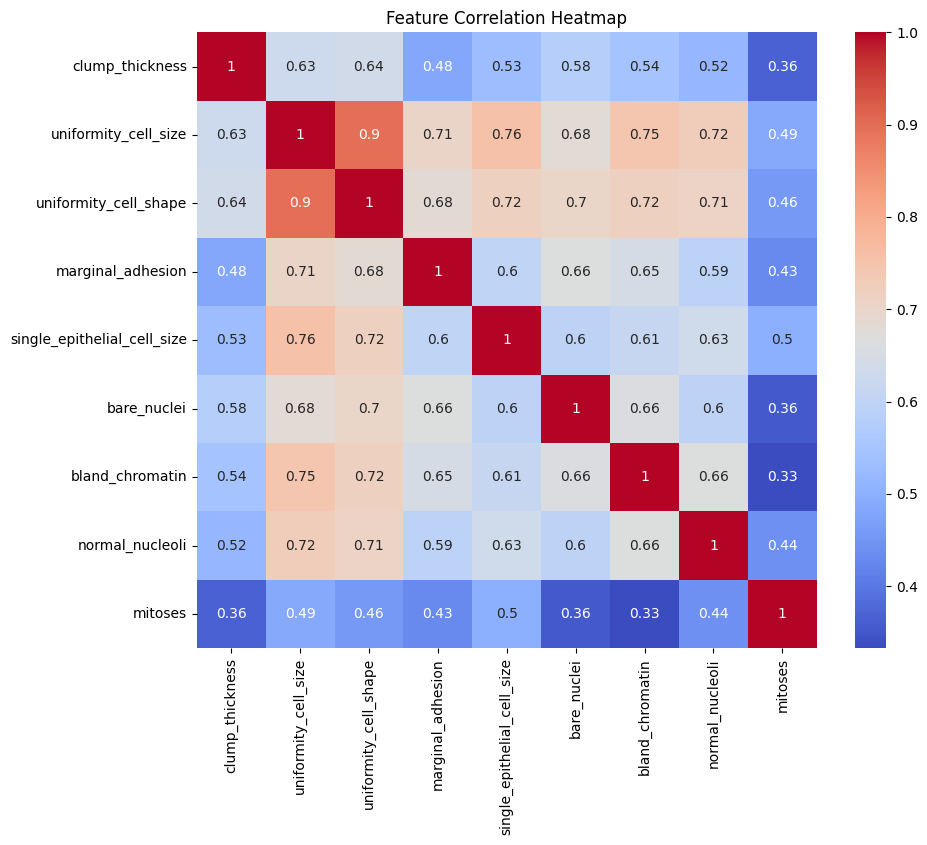

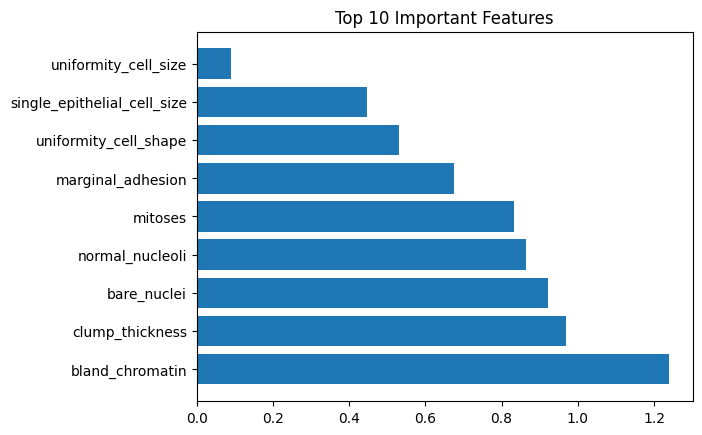

In [9]:
# 6a. Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), cmap='coolwarm', annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()
print('\n\n')


# 6b. Plot top feature importance (bar chart)
feature_importance = pd.DataFrame({
    'Feature': X_all.columns,
    'Importance': np.abs(clf.coef_[0])
}).sort_values('Importance', ascending=False)
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title('Top 10 Important Features')
plt.show()


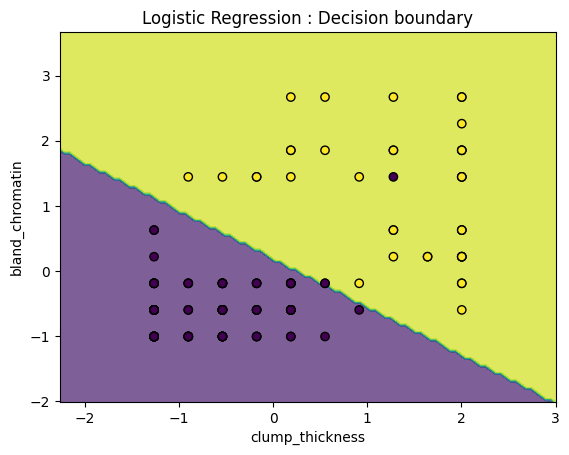

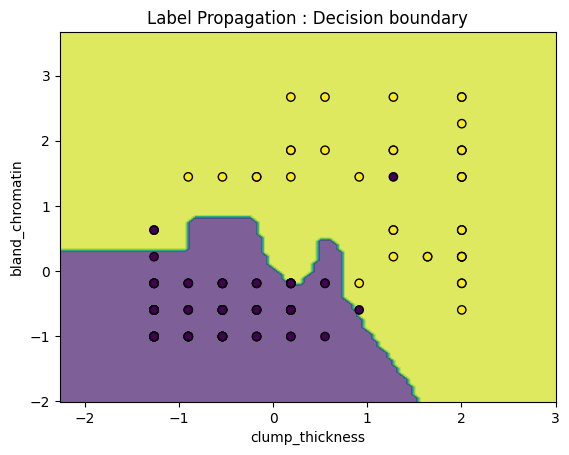

In [10]:
# 6c. Decision boundary plot for at least one 2-feature subset
# --------------------------------------------------
# Supervised Learning decison boundary visualization
# --------------------------------------------------

from sklearn.inspection import DecisionBoundaryDisplay

X_unseen = pd.DataFrame(X_unseen, columns=X_all.columns, index=y_unseen.index)
# Prepare the data
df_labeled = df_ssl[df_ssl["class"] != -1]

X = df_labeled[["clump_thickness", "bland_chromatin"]]
y = df_labeled["class"].astype(int)

X_unseen = X_unseen[["clump_thickness", "bland_chromatin"]]

# Train supervised model
clf = LogisticRegression()
clf.fit(X, y)

y_pred = clf.predict(X_unseen)

disp = DecisionBoundaryDisplay.from_estimator(
    clf, X_unseen, response_method="predict",
    xlabel="clump_thickness", ylabel="bland_chromatin",
    alpha=0.7,
)
disp.ax_.scatter(X_unseen['clump_thickness'], X_unseen['bland_chromatin'], c=y_unseen, edgecolor="k")
plt.title("Logistic Regression : Decision boundary")
plt.show()
print("\n\n")

# --------------------------------------------------
# Semi supervised Learning decison boundary visualization
# --------------------------------------------------

from sklearn.inspection import DecisionBoundaryDisplay

X_unseen = pd.DataFrame(X_unseen, columns=X_all.columns, index=y_unseen.index)
# Prepare the data
df_labeled = df_ssl[df_ssl["class"] != -1]

X = df_labeled[["clump_thickness", "bland_chromatin"]]
y = df_labeled["class"].astype(int)

X_unseen = X_unseen[["clump_thickness", "bland_chromatin"]]

# Train semi supervised model
lp = LabelPropagation()
lp.fit(X, y)

# Predictions
y_pred_lp = lp.predict(X_unseen)

disp = DecisionBoundaryDisplay.from_estimator(
    lp, X_unseen, response_method="predict",
    xlabel="clump_thickness", ylabel="bland_chromatin",
    alpha=0.7,
)
disp.ax_.scatter(X_unseen['clump_thickness'], X_unseen['bland_chromatin'], c=y_unseen, edgecolor="k")
plt.title("Label Propagation : Decision boundary")
plt.show()